In [6]:
import kagglehub

path = kagglehub.dataset_download("anshika2301/ipl-analytics-dataset")

print("Path to dataset files:", path)

100%|██████████| 7.00M/7.00M [00:02<00:00, 3.32MB/s]

Extracting files...
Path to dataset files: /Users/ishu/.cache/kagglehub/datasets/anshika2301/ipl-analytics-dataset/versions/1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("ipl_matches.csv")
df.head(10)

,id,city,match_date,season,match_number,team1,team2,venue,toss_winner,toss_decision,superover,winning_team,won_by,margin,method,player_of_match,umpire1,umpire2
0,1312200,Ahmedabad,29-05-2022,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,27-05-2022,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,CB Gaffaney,Nitin Menon
2,1312198,Kolkata,25-05-2022,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,J Madanagopal,MA Gough
3,1312197,Kolkata,24-05-2022,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,BNJ Oxenford,VK Sharma
4,1304116,Mumbai,22-05-2022,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,AK Chaudhary,NA Patwardhan
5,1304115,Mumbai,21-05-2022,2022,69,Delhi Capitals,Mumbai Indians,"Wankhede Stadium, Mumbai",Mumbai Indians,field,N,Mumbai Indians,Wickets,5.0,NaN,JJ Bumrah,Nitin Menon,Tapan Sharma
6,1304114,Mumbai,20-05-2022,2022,68,Chennai Super Kings,Rajasthan Royals,"Brabourne Stadium, Mumbai",Chennai Super Kings,bat,N,Rajasthan Royals,Wickets,5.0,NaN,R Ashwin,CB Gaffaney,NA Patwardhan
7,1304113,Mumbai,19-05-2022,2022,67,Gujarat Titans,Royal Challengers Bangalore,"Wankhede Stadium, Mumbai",Gujarat Titans,bat,N,Royal Challengers Bangalore,Wickets,8.0,NaN,V Kohli,KN Ananthapadmanabhan,GR Sadashiv Iyer
8,1304112,Navi Mumbai,18-05-2022,2022,66,Lucknow Super Giants,Kolkata Knight Riders,"Dr DY Patil Sports Academy, Mumbai",Lucknow Super Giants,bat,N,Lucknow Super Giants,Runs,2.0,NaN,Q de Kock,R Pandit,YC Barde
9,1304111,Mumbai,17-05-2022,2022,65,Sunrisers Hyderabad,Mumbai Indians,"Wankhede Stadium, Mumbai",Mumbai Indians,field,N,Sunrisers Hyderabad,Runs,3.0,NaN,RA Tripathi,CB Gaffaney,N Pandit


In [11]:
df.isnull()
df.isnull().sum()

id                   0
city                51
match_date           0
season               0
match_number         0
team1                0
team2                0
venue                0
toss_winner          0
toss_decision        0
superover            4
winning_team         4
won_by               0
margin              18
method             931
player_of_match      4
umpire1              0
umpire2              0
dtype: int64

In [21]:
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['superover'] = df['superover'].fillna(df['superover'].mode()[0])
df['winning_team'] = df['winning_team'].fillna(df['winning_team'].mode()[0])
df['margin'] = df['margin'].fillna(df['margin'].mode()[0])
df['method'] = df['method'].fillna(df['method'].mode()[0])
df['player_of_match'] = df['player_of_match'].fillna(df['player_of_match'].mode()[0])
df.isnull().sum()

id                 0
city               0
match_date         0
season             0
match_number       0
team1              0
team2              0
venue              0
toss_winner        0
toss_decision      0
superover          0
winning_team       0
won_by             0
margin             0
method             0
player_of_match    0
umpire1            0
umpire2            0
dtype: int64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               950 non-null    int64  
 1   city             950 non-null    str    
 2   match_date       950 non-null    str    
 3   season           950 non-null    str    
 4   match_number     950 non-null    str    
 5   team1            950 non-null    str    
 6   team2            950 non-null    str    
 7   venue            950 non-null    str    
 8   toss_winner      950 non-null    str    
 9   toss_decision    950 non-null    str    
 10  superover        950 non-null    str    
 11  winning_team     950 non-null    str    
 12  won_by           950 non-null    str    
 13  margin           950 non-null    float64
 14  method           950 non-null    str    
 15  player_of_match  950 non-null    str    
 16  umpire1          950 non-null    str    
 17  umpire2          950 non-nu

In [24]:
df.shape

(950, 18)

In [26]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 950 and your columns are 18


In [30]:
match_winner = df['winning_team'].value_counts()
match_winner

winning_team
Mumbai Indians                 135
Chennai Super Kings            121
Kolkata Knight Riders          114
Royal Challengers Bangalore    109
Rajasthan Royals                96
Kings XI Punjab                 88
Sunrisers Hyderabad             75
Delhi Daredevils                67
Delhi Capitals                  36
Deccan Chargers                 29
Punjab Kings                    13
Gujarat Lions                   13
Gujarat Titans                  12
Pune Warriors                   12
Rising Pune Supergiant          10
Lucknow Super Giants             9
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

/var/folders/ny/lvg9d94578v551c7ylgq0nmh0000gn/T/ipykernel_83281/3083942077.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y = match_winner.index , x = match_winner.values ,  palette = "viridis")


Text(0.5, 1.0, 'Most match winners ')

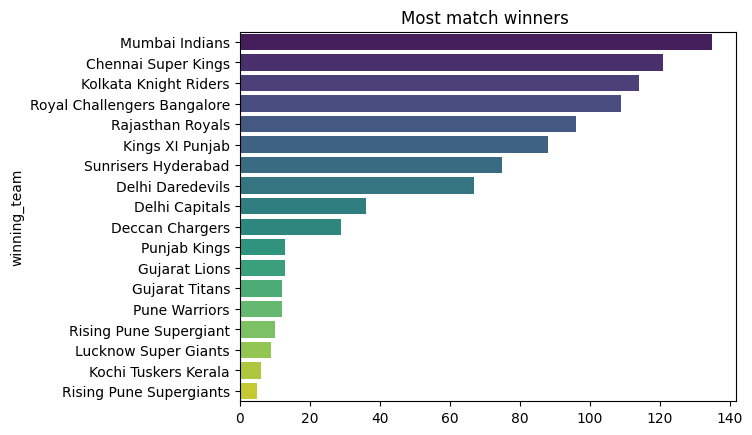

In [33]:
sns.barplot(y = match_winner.index , x = match_winner.values ,  palette = "viridis")
plt.title("Most match winners ")

<Axes: xlabel='toss_decision', ylabel='count'>

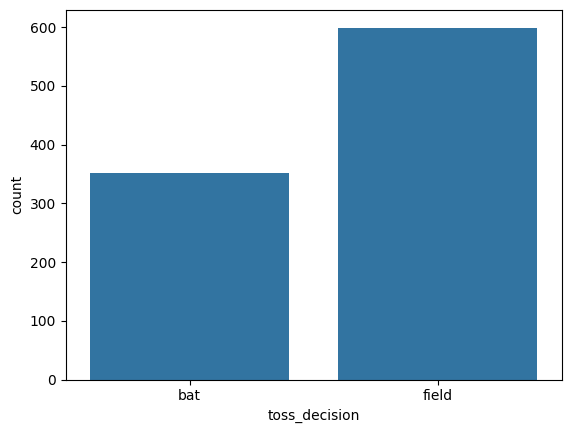

In [35]:
sns.countplot(x = df['toss_decision'])

In [46]:
count = df[df['toss_winner'] == df['winning_team']]['id'].count()
percantage = (count * 100)/df.shape[0]
percantage.round(2)

np.float64(51.47)

<Axes: xlabel='won_by', ylabel='count'>

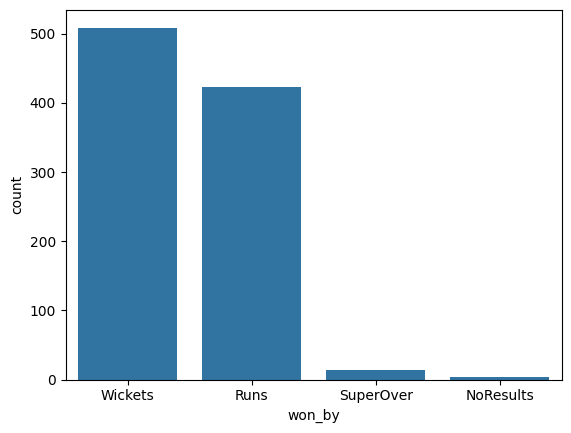

In [47]:
sns.countplot( x = df['won_by'])

In [50]:
count = df['player_of_match'].value_counts().head(10)
count

player_of_match
AB de Villiers    29
CH Gayle          22
DA Warner         18
RG Sharma         18
MS Dhoni          17
SR Watson         16
YK Pathan         16
V Kohli           14
KA Pollard        14
SK Raina          14
Name: count, dtype: int64

/var/folders/ny/lvg9d94578v551c7ylgq0nmh0000gn/T/ipykernel_83281/3942701444.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = count.values ,  y = count.index , palette = 'mako')


Text(0.5, 1.0, 'Top 10 players with man of the match')

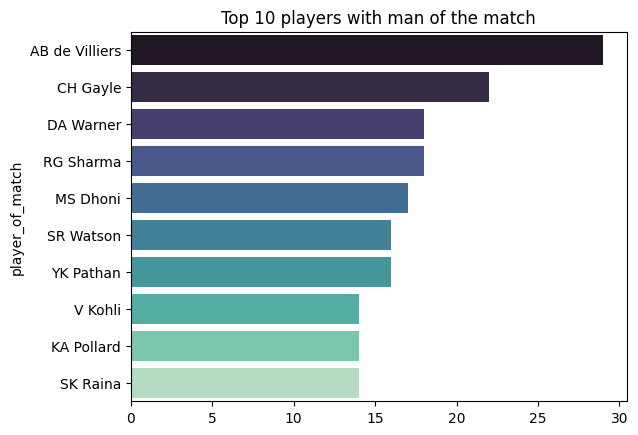

In [54]:
sns.barplot(x = count.values ,  y = count.index , palette = 'mako')
plt.title("Top 10 players with man of the match")

In [57]:
count_venue = df['venue'].value_counts().head(10)
count_venue

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Punjab Cricket Association Stadium, Mohali    35
Wankhede Stadium, Mumbai                      31
Name: count, dtype: int64

/var/folders/ny/lvg9d94578v551c7ylgq0nmh0000gn/T/ipykernel_83281/3467000825.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = count_venue.values , y = count_venue.index , palette = 'rainbow')


<Axes: ylabel='venue'>

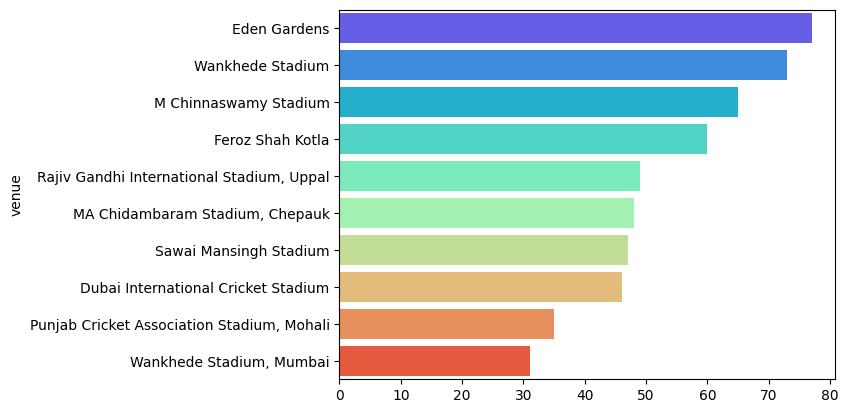

In [58]:
sns.barplot(x = count_venue.values , y = count_venue.index , palette = 'rainbow')

In [64]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin' , ascending=False).head(1)[['winning_team' , 'margin']]

,winning_team,margin
329,Mumbai Indians,146.0
